In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate
import math
import lab_funcs as lf
import my_funcs as mf

# Методы Монте-Карло

## Задание 1
1. Вычислите методом Монте-Карло объемы $D$-мерных шаров радиуса $R=1$ для $D=1\ldots 15$ с выборками размера $N=1\ldots 10^6$.
Постройте график зависимости средней квадратической относительной ошибки объема от $N$ для разных $D$. Оцените асимптотику ошибки при $N\to\infty$.

2. Теоретически обоснуйте наблюдаемую зависимость средней квадратической ошибки от размера выборки.

3. Как можно оценить предельную ошибку вычисления интеграла методом Монте-Карло?

4. Сравните ошибку метода Монте-Карло с результатами лабораторной [про квадратурные формулы](Integration.ipynb). Для каких размерностей $D$ метод Монте-Карло оказывается точнее, чем вычисление через произведение составных формул Симпсона по каждой из координат?

### Решение 1

#### 1.

Данные интегралы считаются через метод Монте-Карло. Краткая идея состоит в том, что матожидание есть интеграл, и к матожиданию стремится среднее выборки случайных величи по ЗБЧ. И тем самым сгенерировав достаточную выборку, мы можем оценить или даже вычислить интеграл. Приведем выкладки:

$$
E_p[f] = \int_{\Omega} f(x)p(x) dx
$$

$$
E_p[f] \approx M_N = \frac{1}{N}\sum_{n=1}^N f(x_n),
$$

---
ЗБЧ:

Пусть $X_1, X_2, \dots, X_N$ — независимые одинаково распределённые случайные величины с математическим ожиданием $E[X_i] = \mu$.

Тогда их среднее:

$$
M_N = \frac{1}{N} \sum_{k=1}^{N} X_k
$$

сходится к математическому ожиданию:

$$
M_N \xrightarrow[N \to \infty]{} \mu
$$

(сходимость по вероятности — слабый закон больших чисел)


ЦПТ:

Пусть дополнительно дисперсия конечна: $\mathrm{Var}(X_i) = \sigma^2$.

Тогда

$$
\sqrt{N}\left(M_N - \mu\right)
\xrightarrow[N \to \infty]{d}
\mathcal{N}(0, \sigma^2)
$$

или эквивалентно:

$$
M_N \approx \mathcal{N}\left(\mu, \frac{\sigma^2}{N}\right)
$$


Для оценки интеграла:

$$
\frac{1}{N} \sum_{k=1}^{N} f(x_k)
$$

ошибка имеет порядок:

$$
\text{ошибка} \sim O\left(\frac{1}{\sqrt{N}}\right)
$$

и стандартное отклонение:

$$
\sigma(M_N) = \frac{\sigma}{\sqrt{N}}
$$

---

Для вычисления обьема $D$ шара $B=\{x\in\mathbb R^D\colon |x|^2\leq 1\},$
мы возьмем случайную величину $X$ равномерно распределенную на кубе $\Omega=[-1,1]^{\times D}$.
Воспользуемся очевидными тождествами:
$$
\frac{V(B)}{V(\Omega)}=P\{X\in B\}=E[1_B],
$$
где $1_B$ - характеристическая функция множества $B$:

$$
1_B(x)=\begin{cases}
1,&x\in B,\\
0,&x\notin B.
\end{cases}
$$

$$p(x) = \frac{1}{V(\Omega)}$$

$$E[1_B] = \int_{\Omega} 1_B(x) p(x) dx = \frac{1}{V(\Omega)} \cdot \int_{\Omega} 1_B(x)dx$$

$$V(B) = \int_{\Omega} 1_B(x)dx$$

Проинтегрируем и получим графики для объемов $D$-мерных шаров радиуса $R=1$ для $D=1\ldots 15$ с выборками размера $N=1\ldots 10^6$

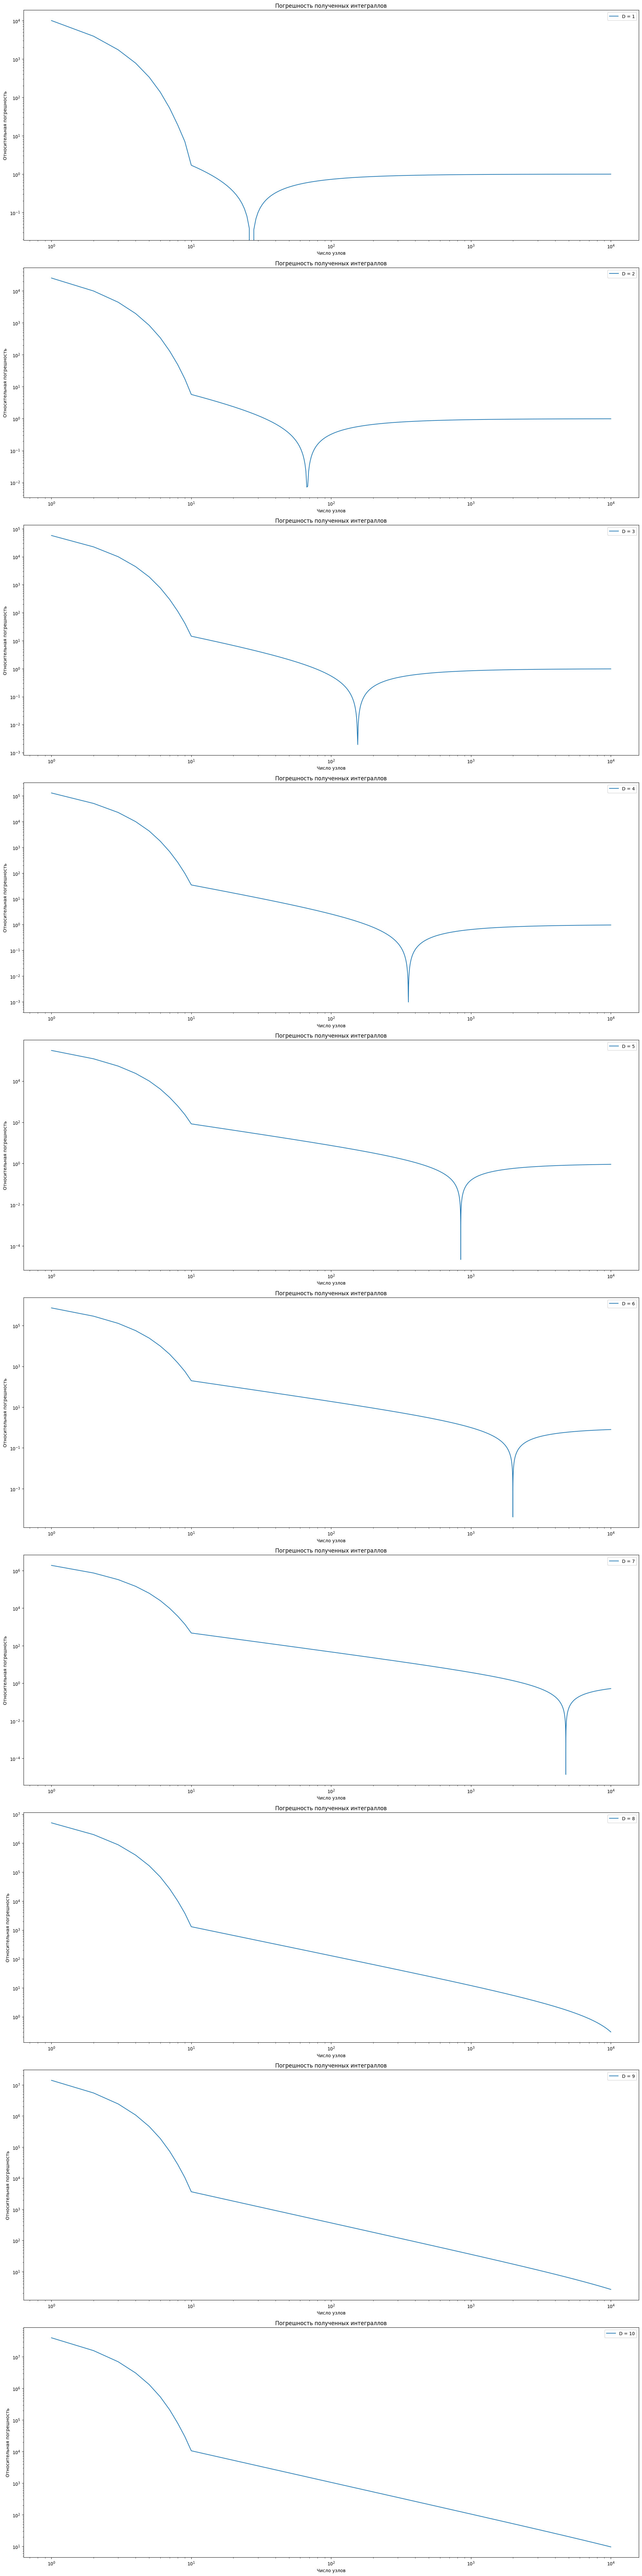

In [26]:
from scipy.special import gamma

def get_volum_of_N_dim_ball_by_teor(n, R):
    return (np.power(np.pi, (n/2)) / gamma(n/2 + 1)) * np.power(R, n)

def get_volume_of_n_dim_ball_by_Monte_Karlo(n, R, sz_seq, rand_seq):

    is_x_in_B = np.sum(np.power(rand_seq, 2), axis=1)<1

    x_in_B_count = np.sum(is_x_in_B)

    p_x_in_B = x_in_B_count / sz_seq

    V_Omega = np.power((2*R), n)

    V_B_estimated = p_x_in_B * V_Omega

    return V_B_estimated


# set params
D = np.arange(10)+1
N = np.arange(10**4)+1
R = 1

# generate random sequence
numb_seq = 10
rand_sequences = np.random.rand(numb_seq, D.size, N.size)*2-1 

rand_seq = rand_sequences.mean(axis=0)
 

# find volumes
volume_teor = get_volum_of_N_dim_ball_by_teor(D, R)
data = np.empty((D.size, N.size))

for cur_dim in D:
    for cur_sz_seq in N:
        data[cur_dim-1][cur_sz_seq-1] = get_volume_of_n_dim_ball_by_Monte_Karlo(cur_dim, R, cur_sz_seq, rand_sequences[:cur_dim, :cur_sz_seq])


# find relative errors
data_rel_err = np.empty(data.shape)

for cur_dim in D:
    for cur_sz_seq in N:
        data_rel_err[cur_dim-1][cur_sz_seq-1] = lf.get_relative_err(data[cur_dim-1][cur_sz_seq-1], volume_teor[cur_dim-1])


#plot
fig, ax = plt.subplots(D.size, 1, figsize=(20, 80))
for cur_dim in D:
    ax[cur_dim-1].loglog(N, data_rel_err[cur_dim-1][:], label=("D = " + str(cur_dim)))
    ax[cur_dim-1].set_xlabel('Число узлов')
    ax[cur_dim-1].set_ylabel('Относительная погрешность')
    ax[cur_dim-1].set_title('Погрешность полученных интеграллов')
    ax[cur_dim-1].legend()

fig.tight_layout()


